# Detached EEG Pipeline (Standalone)

This notebook contains the full pipeline code from `src/pipeline.py` and is ready to be run on Google Colab. Make sure you select a **GPU runtime**.

> **⚡ Auto-Reconnect Support**: This notebook has two-level checkpointing. If Colab disconnects, simply re-run all cells from the top — the pipeline automatically resumes from the last completed fold *without* repeating the expensive GPU pre-transformation step.

### 🔄 Restart / Recovery Instructions

Google Colab Pay-as-you-go runtimes can disconnect at any time. This notebook is designed to recover automatically.

#### On first run
Run all cells top-to-bottom as normal.

#### After a disconnection
1. **Re-run all cells from the top** (Runtime → Run all).
2. The pipeline will automatically:
   - Load the **feature matrix cache** from `results/cache/` on Drive (skips the slow GPU pre-transformation step).
   - Resume the **LOSO loop** from the last completed fold (reads `results/loso_results.json`).

#### Cache locations on Google Drive
| File | Contents |
|------|----------|
| `results/cache/feature_matrix_{m}.npy` | Pre-computed feature matrices (10 files) |
| `results/cache/X_all.npy`, `y_all.npy`, `s_indices.npy` | Formatted EEG data |
| `results/cache/cache_meta.json` | Cache config hash for invalidation |
| `results/loso_results.json` | Fold results (updated after each fold) |

#### Forcing a full recompute
Delete `results/cache/` from Drive, then re-run. This is necessary if you change `num_models`, `num_kernels`, or the dataset path.

> **Note:** The keep-alive cell below prevents *idle-timeout* disconnections. Re-run it after every reconnect.

In [1]:
# Mount Google Drive if you have uploaded your dataset here
from google.colab import drive
drive.mount('/content/drive')

# Change to the directory where your detachment-eeg code and data live
import os
os.chdir('/content/drive/MyDrive/Colab')
print("Working directory:", os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/drive/MyDrive/Colab


In [2]:
import os
import sys

# Ensure the current working directory is added to Python path for local imports.
# This might be redundant if os.chdir is effective, but acts as a safeguard.
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

# Install Dependencies
!pip install mne numpy scikit-learn pyts torch matplotlib sktime==0.30.0
!pip install git+https://github.com/gon-uri/detach_rocket --quiet

  Preparing metadata (setup.py) ... done


In [3]:
# ── Colab Keep-Alive ────────────────────────────────────────────────────────
# Prevents idle-timeout disconnection by simulating activity every 60 seconds.
# Re-run this cell after every reconnect.
# Note: this only prevents IDLE timeouts, not runtime session limits (~12h).
# For session limits, the cache-based restart strategy handles recovery.
from IPython.display import display, Javascript

display(Javascript('''
function ClickConnect(){
    console.log("[keep-alive] Simulating activity to prevent idle timeout.");
    var btn = document.querySelector("colab-toolbar-button#connect");
    if (btn) btn.click();
}
setInterval(ClickConnect, 60000);
'''))
print("✓ Keep-alive activated (fires every 60s). Re-run this cell after each reconnect.")

<IPython.core.display.Javascript object>

✓ Keep-alive activated (fires every 60s). Re-run this cell after each reconnect.


### Imports and Setup

In [4]:
import mne
import numpy as np
import json
import os
from typing import Dict, Any, List
from sklearn.metrics import accuracy_score, classification_report

# Add the project root directory to Python path for robust imports
import sys
project_root = '/content/drive/MyDrive/Colab'
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Now import from src.utl
from src.utl.config import load_config
from src.utl.bids import load_bids_dataset
from src.utl.splits import get_stratified_splits
from src.utl.eeg import load_and_format_data

# Import Detach Rocket
try:
    from detach_rocket.detach_classes import DetachEnsemble
except ImportError:
    try:
        from detach_rocket.detach_rocket import DetachEnsemble
    except ImportError:
        print("Warning: detach_rocket not installed correctly. Using placeholder.")
        DetachEnsemble = None

# Make MNE quieter
mne.set_log_level("WARNING")

### Pipeline Class Definition

In [5]:
class TaskEEGPipeline:
    """
    EEG Classification Pipeline utilizing Detach-Rocket Ensemble.

    This implementation replicates the methodology from arxiv:2408.02760,
    achieving ~84.6% subject-level accuracy on the 65-subject AD vs CN task
    (Paper Benchmark: 86.15%).

    Key Features:
    - GPU-accelerated MiniRocket transformations (via PyTorch)
    - Pre-transformation strategy for efficient LOSO cross-validation
    - Weighted Ensemble voting based on training accuracy
    - Leave-One-Subject-Out (LOSO) validation scheme
    - Two-level checkpointing for Colab disconnection recovery:
        Level 1: Feature matrix cache saved to Drive after pre-transformation.
        Level 2: Fold results saved to loso_results.json after each fold.
    """
    def __init__(self, config_path: str = "config.yml"):
        self.config = load_config(config_path)

        # Load experiment settings
        exp_config = self.config.get('experiment', {})
        dataset_key = exp_config.get('dataset', 'photic')
        self.data_path = self.config['data'].get(dataset_key, self.config['data']['photic'])

        self.split_seed = exp_config.get('seed', 42)
        self.n_splits = exp_config.get('n_splits', 5)
        self.binary_mode = exp_config.get('binary_classification', True)

        self.df: Any = None
        self.subjects: Dict[str, List[str]] | None = None
        self.splits: List[Dict[str, Any]] | None = None
        self.processed_folds_data: List[Dict[str, Any]] = []
        self.completed_subjects: List[str] = []

        # Indicate CUDA status at the start
        self._check_cuda()

    # =========================================================================
    # Hardware Check
    # =========================================================================

    def _check_cuda(self):
        """
        Check and log hardware acceleration status.
        Crucial for processing 10k+ kernels across 10+ ensemble models.
        """
        try:
            import torch
            cuda_available = torch.cuda.is_available()
            print(f"\n" + "="*30)
            print(f"CUDA STATUS CHECK")
            print(f"="*30)
            print(f"CUDA Available: {'YES' if cuda_available else 'NO'}")
            if cuda_available:
                print(f"Device Name: {torch.cuda.get_device_name(0)}")
                print(f"VRAM Total: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
            print(f"="*30 + "\n")
        except ImportError:
            print("\n[!] PyTorch not installed. Cannot check CUDA status.\n")
        except Exception as e:
            print(f"\n[!] Error checking CUDA: {e}\n")

    # =========================================================================
    # Initialization & Split Preparation
    # =========================================================================

    def initialize(self):
        """Discover files and prepare splits, loading any existing fold checkpoints."""
        print(f"Initializing pipeline with data at: {self.data_path}")
        self.df, (controls, ad, ftd) = load_bids_dataset(self.data_path)

        if self.df is not None and self.df.empty:
            print("No data found. Check your config.yml paths.")
            return

        n_processed = self.df[self.df['is_derivative'] == True].shape[0] if 'is_derivative' in self.df.columns else 0
        print(f"Discovered {len(self.df)} EEG records ({n_processed} from derivatives).")

        # Filtering for AD vs CN as per Section 5.2 of the paper
        print(f"Total discovered subjects: {len(controls)} Control, {len(ad)} AD, {len(ftd)} FTD.")

        # Apply subject limit if specified
        exp_config = self.config.get('experiment', {})
        max_subjects = exp_config.get('max_subjects')
        if max_subjects:
            half = max_subjects // 2
            controls = controls[:half]
            ad = ad[:max_subjects - half]
            print(f"Limiting to {len(controls)} Control and {len(ad)} AD subjects (Total: {len(controls) + len(ad)}).")
        else:
            print("Replicating Section 5.2: Focusing on AD vs CN classification (total 65 subjects).")

        self.subjects = {"Control": controls, "AD": ad}

        # LOSO (Leave-One-Subject-Out) Cross-validation subjects
        loso_subjects = controls + ad

        # ── Level 2 Checkpoint: Load completed fold results ────────────────────
        results_path = "results/loso_results.json"
        if os.path.exists(results_path) and os.path.getsize(results_path) > 0:
            try:
                with open(results_path, "r") as f:
                    all_runs_results = json.load(f)
                    if isinstance(all_runs_results, list) and all_runs_results:
                        last_run_results = all_runs_results[-1]  # Most recent run
                        self.processed_folds_data = last_run_results.get("folds", [])
                        self.completed_subjects = [fold["subject"] for fold in self.processed_folds_data]
                        print(f"Found {len(self.completed_subjects)} completed folds from previous run.")
                        print(f"Completed subjects: {', '.join(self.completed_subjects)}")
            except json.JSONDecodeError:
                print(f"Warning: Existing '{results_path}' is not valid JSON. Starting fresh.")
            except Exception as e:
                print(f"Error reading '{results_path}': {e}. Starting fresh.")

        # Filter out subjects already processed
        remaining_loso_subjects = [sub for sub in loso_subjects if sub not in self.completed_subjects]

        if not remaining_loso_subjects:
            print("All subjects already processed. No new folds to run.")
            self.splits = []
            return

        print(f"Remaining subjects to process: {len(remaining_loso_subjects)}.")

        self.splits = []
        for i, test_sub in enumerate(remaining_loso_subjects):
            # Train on ALL other subjects from the *original* list
            train_subs = [s for s in loso_subjects if s != test_sub]
            self.splits.append({
                "train_subjects": train_subs,
                "test_subjects": [test_sub],
                "val_idx": loso_subjects.index(test_sub)
            })

        print(f"Generated {len(self.splits)} new LOSO cross-validation folds to run.")

    # =========================================================================
    # Level 1 Checkpoint: Feature Matrix Cache
    # =========================================================================

    def _get_cache_key(self):
        """
        Generate a hash from the relevant config entries.
        Used to detect when the cache is stale and must be invalidated
        (e.g., after changing num_models, num_kernels, or the dataset path).
        """
        import hashlib
        model_params = self.config.get('model', {}).get('params', {})
        key_parts = {
            "num_models": model_params.get('num_models', 10),
            "num_kernels": model_params.get('num_kernels', 10000),
            "data_path": self.data_path,
        }
        key_str = json.dumps(key_parts, sort_keys=True)
        return hashlib.md5(key_str.encode()).hexdigest()

    def _save_precomputed_cache(self, X_all, y_all, s_indices, feature_matrices):
        """
        Persist the pre-computed feature matrices (and raw formatted data) to Drive.

        This is called once after the GPU pre-transformation step completes.
        On all future restarts, _load_precomputed_cache() will find these files
        and skip the expensive computation entirely.

        Cache layout (under results/cache/):
            X_all.npy, y_all.npy, s_indices.npy  — formatted EEG data
            feature_matrix_{m}.npy                — one file per ensemble model
            cache_meta.json                       — config hash for invalidation
        """
        import datetime
        cache_dir = "results/cache"
        os.makedirs(cache_dir, exist_ok=True)

        sep = "=" * 55
        print(f"\n{sep}")
        print("SAVING FEATURE MATRIX CACHE TO DRIVE")
        print(sep)
        print("This is a one-time cost. Future restarts will load from cache.")

        np.save(os.path.join(cache_dir, "X_all.npy"), X_all)
        np.save(os.path.join(cache_dir, "y_all.npy"), y_all)
        np.save(os.path.join(cache_dir, "s_indices.npy"), s_indices)
        print(f"  Saved raw formatted data (X_all: {X_all.shape}, y_all: {y_all.shape}).")

        for m, F in enumerate(feature_matrices):
            np.save(os.path.join(cache_dir, f"feature_matrix_{m}.npy"), F)
            print(f"  Saved feature matrix {m+1}/{len(feature_matrices)} — shape: {F.shape}.")

        cache_meta = {
            "cache_key": self._get_cache_key(),
            "num_models": len(feature_matrices),
            "X_all_shape": list(X_all.shape),
            "created_at": datetime.datetime.utcnow().isoformat()
        }
        with open(os.path.join(cache_dir, "cache_meta.json"), "w") as f:
            json.dump(cache_meta, f, indent=4)

        print(f"  Saved cache metadata → '{cache_dir}/cache_meta.json'.")
        print(f"{sep}")
        print("Cache saved. The LOSO loop can now be resumed after any disconnection.")
        print(f"{sep}\n")

    def _load_precomputed_cache(self):
        """
        Attempt to load pre-computed feature matrices and data from Drive.

        Performs automatic cache invalidation: if the config has changed
        since the cache was written (different num_models, num_kernels, or
        data path), the cache is considered stale and None is returned.

        Returns:
            tuple: (X_all, y_all, s_indices, feature_matrices) on cache HIT.
            None: on cache MISS — caller must recompute.
        """
        cache_dir = "results/cache"
        meta_path = os.path.join(cache_dir, "cache_meta.json")

        if not os.path.exists(meta_path):
            print("No feature matrix cache found. Will compute from scratch.")
            return None

        try:
            with open(meta_path, "r") as f:
                cache_meta = json.load(f)
        except Exception as e:
            print(f"Could not read cache metadata ({e}). Recomputing from scratch.")
            return None

        current_key = self._get_cache_key()
        if cache_meta.get("cache_key") != current_key:
            print("[!] Config changed since cache was built — cache invalidated. Recomputing.")
            return None

        model_params = self.config.get('model', {}).get('params', {})
        num_models = model_params.get('num_models', 10)

        sep = "=" * 55
        print(f"\n{sep}")
        print("CACHE HIT — Loading pre-computed feature matrices")
        print(sep)
        print(f"Cache created at: {cache_meta.get('created_at', 'unknown')}")
        print(f"Loading {num_models} feature matrices from '{cache_dir}/'...")

        try:
            X_all = np.load(os.path.join(cache_dir, "X_all.npy"))
            y_all = np.load(os.path.join(cache_dir, "y_all.npy"))
            s_indices = np.load(os.path.join(cache_dir, "s_indices.npy"))
            print(f"  Loaded X_all: {X_all.shape}, y_all: {y_all.shape}")

            feature_matrices = []
            for m in range(num_models):
                F = np.load(os.path.join(cache_dir, f"feature_matrix_{m}.npy"))
                feature_matrices.append(F)
                print(f"  Loaded feature matrix {m+1}/{num_models} — shape: {F.shape}")

            print(f"{sep}")
            print(f"All {num_models} feature matrices loaded. Pre-transformation step SKIPPED.")
            print(f"{sep}\n")
            return X_all, y_all, s_indices, feature_matrices

        except Exception as e:
            print(f"Error loading cache files ({e}). Recomputing from scratch.")
            return None

    # =========================================================================
    # Main Run
    # =========================================================================

    def run(self):
        """
        Execute the optimized pipeline with two-level checkpointing.

        Strategy:
          Level 1 — Feature Matrix Cache:
            Pre-computed feature matrices are saved to Drive after the first run.
            Restarts load them directly, skipping the expensive GPU pre-transformation.

          Level 2 — Per-Fold Checkpoints:
            loso_results.json is updated after every fold, so restarts resume
            from the last completed fold.
        """
        if self.df is None:
            self.initialize()

        if self.df is None or self.df.empty:
            print("Pipeline not initialized or no data found. Aborting.")
            return

        if DetachEnsemble is None:
            print("Detach ROCKET is not available. Aborting.")
            return

        if not self.splits and not self.processed_folds_data:
            print("No splits to process and no previous data to report. Aborting.")
            return

        # Import here so both the cache and LOSO paths have access to DetachMatrix.
        from detach_rocket.detach_classes import PytorchMiniRocketMultivariate, DetachMatrix
        import torch
        device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

        all_original_loso_subjects = self.subjects["Control"] + self.subjects["AD"]

        # ── Level 1 Checkpoint: Feature Matrix Cache ───────────────────────────
        cache_result = self._load_precomputed_cache()

        if cache_result is not None:
            # CACHE HIT: skip data loading + pre-transformation entirely.
            X_all, y_all, s_indices, feature_matrices = cache_result
            print(f"Using cached data: {X_all.shape[0]} trials across {len(all_original_loso_subjects)} subjects.")
        else:
            # CACHE MISS: load raw data and run pre-transformation, then save.

            # 1. Load ALL data for all relevant subjects into RAM once.
            print(f"\nLoading and formatting data for all {len(all_original_loso_subjects)} subjects into RAM...")
            max_trials = self.config.get('experiment', {}).get('max_trials_per_subject')
            X_all, y_all, s_indices = load_and_format_data(
                self.df, all_original_loso_subjects, max_trials_per_subject=max_trials
            )

            if X_all.size == 0:
                print("No data could be loaded. Aborting.")
                return

            print(f"Total trials loaded: {X_all.shape[0]} across {len(all_original_loso_subjects)} subjects.")
            print(f"Data shape: {X_all.shape}")

            # 2. Pre-Transformation Strategy: Transform all data into feature space ONCE.
            #    This avoids 65x redundant convolution operations in the LOSO loop.
            model_params = self.config.get('model', {}).get('params', {})
            num_models = model_params.get('num_models', 10)
            num_kernels = model_params.get('num_kernels', 10000)

            print(f"\nInitializing {num_models} Detach-Rocket transformers (Target: {num_kernels} kernels each)...")

            transformers = []
            feature_matrices = []

            for m in range(num_models):
                print(f"Creating Feature Matrix for Model {m+1}/{num_models}...")
                transformer = PytorchMiniRocketMultivariate(num_features=num_kernels, device=device)
                transformer.fit(X_all)
                F = transformer.transform(X_all).numpy()
                transformers.append(transformer)
                feature_matrices.append(F)

            # Save to Drive IMMEDIATELY — if Colab disconnects before the LOSO loop
            # finishes, the next restart will load from here and skip this step.
            self._save_precomputed_cache(X_all, y_all, s_indices, feature_matrices)

        # ── Level 2 Checkpoint: Per-Fold Results ───────────────────────────────
        # 3. Start LOSO loop using the pre-calculated features.
        print("\nStarting Optimized LOSO Cross-Validation Loop...")

        # Initialize with any previously completed folds (loaded in initialize())
        subject_predictions = [fold['y_pred'] for fold in self.processed_folds_data]
        subject_true_labels = [fold['y_true'] for fold in self.processed_folds_data]
        results = list(self.processed_folds_data)

        sub_to_idx = {sub_id: i for i, sub_id in enumerate(all_original_loso_subjects)}

        for i, split in enumerate(self.splits):
            test_sub_id = split['test_subjects'][0]
            print(f"\n--- Fold {len(results)+1}/{len(all_original_loso_subjects)} (Testing: {test_sub_id}) ---")

            test_sub_idx_in_all = sub_to_idx[test_sub_id]
            train_mask = s_indices != test_sub_idx_in_all
            test_mask = s_indices == test_sub_idx_in_all

            y_train = y_all[train_mask]
            y_test = y_all[test_mask]

            model_outputs = []
            model_weights = []

            for m in range(len(feature_matrices)):
                F_train = feature_matrices[m][train_mask]
                F_test = feature_matrices[m][test_mask]

                model = DetachMatrix(
                    trade_off=self.config.get('experiment', {}).get('trade_off', 0.1)
                )
                model.fit(F_train, y_train)
                y_pred_m = model.predict(F_test)
                model_outputs.append(y_pred_m)
                model_weights.append(model._acc_train)

            # 4. Ensemble Voting (weighted by training accuracy)
            model_outputs = np.array(model_outputs).T
            weights = np.array(model_weights)

            y_pred_probas = (model_outputs * weights).sum(axis=1) / weights.sum()
            y_pred_trials = (y_pred_probas >= 0.5).astype(int)

            # Subject-level prediction via majority vote across trials
            y_pred_subject = 1 if np.mean(y_pred_trials) >= 0.5 else 0
            y_true_subject = y_test[0]

            subject_predictions.append(y_pred_subject)
            subject_true_labels.append(y_true_subject)

            results.append({
                "subject": test_sub_id,
                "y_true": int(y_true_subject),
                "y_pred": int(y_pred_subject),
                "trial_accuracy": float(accuracy_score(y_test, y_pred_trials))
            })

            print(f"Subject Prediction: {y_pred_subject} (True: {y_true_subject})")

            # Save fold checkpoint immediately after each fold
            self._save_results_checkpoint(
                subject_predictions, subject_true_labels, results, all_original_loso_subjects
            )

        # 5. Final Report
        if subject_predictions:
            final_acc = accuracy_score(subject_true_labels, subject_predictions)
            print(f"\nFinal Subject-Level Accuracy (LOSO): {final_acc*100:.2f}%")
            print("\nClassification Report:")
            print(classification_report(subject_true_labels, subject_predictions, target_names=['Control', 'AD']))
            print("\nFinal results (including all folds) saved to results/loso_results.json")

    # =========================================================================
    # Level 2 Checkpoint: Per-Fold Results
    # =========================================================================

    def _save_results_checkpoint(self, subject_predictions, subject_true_labels, current_folds_results, all_original_loso_subjects):
        os.makedirs("results", exist_ok=True)
        json_path = "results/loso_results.json"

        # Prepare current run's results with full config and params
        current_run_results = {
            "config": self.config,
            "model_params": {
                "num_models": self.config.get('model', {}).get('params', {}).get('num_models', 10),
                "num_kernels": self.config.get('model', {}).get('params', {}).get('num_kernels', 10000),
                "trade_off": self.config.get('experiment', {}).get('trade_off', 0.1)
            },
            "subject_level_accuracy": accuracy_score(subject_true_labels, subject_predictions) if len(subject_predictions) > 0 else 0.0,
            "paper_target_accuracy": 0.8615,
            "folds": current_folds_results
        }

        all_runs_results = []
        if os.path.exists(json_path) and os.path.getsize(json_path) > 0:
            try:
                with open(json_path, "r") as f:
                    existing_data = json.load(f)
                    if isinstance(existing_data, list):
                        all_runs_results = existing_data
                    else:  # Legacy single-object format
                        all_runs_results.append(existing_data)
            except json.JSONDecodeError:
                print(f"Warning: Existing '{json_path}' is not valid JSON. Starting fresh.")
            except Exception as e:
                print(f"Error reading '{json_path}': {e}. Starting fresh.")

        # Update the last run's entry if config matches, else append a new run.
        if len(all_runs_results) > 0:
            last_saved_run_config = all_runs_results[-1].get("config")
            if last_saved_run_config == self.config:
                all_runs_results[-1] = current_run_results
                experiment_number = all_runs_results[-1].get("experiment_number", len(all_runs_results))
            else:
                experiment_number = len(all_runs_results) + 1
                current_run_results["experiment_number"] = experiment_number
                all_runs_results.append(current_run_results)
        else:
            experiment_number = 1
            current_run_results["experiment_number"] = experiment_number
            all_runs_results.append(current_run_results)

        with open(json_path, "w") as f:
            json.dump(all_runs_results, f, indent=4)
        print(f"Checkpoint saved for experiment {experiment_number} to {json_path} "
              f"(processed {len(current_folds_results)}/{len(all_original_loso_subjects)} folds).")

### Run the Pipeline

In [6]:
if __name__ == "__main__":
    pipeline = TaskEEGPipeline()
    pipeline.run()


CUDA STATUS CHECK
CUDA Available: YES
Device Name: NVIDIA L4
VRAM Total: 22.03 GB

Initializing pipeline with data at: ./data/processed/ds006036
Discovered 88 EEG records (0 from derivatives).
Total discovered subjects: 29 Control, 36 AD, 23 FTD.
Replicating Section 5.2: Focusing on AD vs CN classification (total 65 subjects).
Found 54 completed folds from previous run.
Completed subjects: sub-037, sub-038, sub-039, sub-040, sub-041, sub-042, sub-043, sub-044, sub-045, sub-046, sub-047, sub-048, sub-049, sub-050, sub-051, sub-052, sub-053, sub-054, sub-055, sub-056, sub-057, sub-058, sub-059, sub-060, sub-061, sub-062, sub-063, sub-064, sub-065, sub-001, sub-002, sub-003, sub-004, sub-005, sub-006, sub-007, sub-008, sub-009, sub-010, sub-011, sub-012, sub-013, sub-014, sub-015, sub-016, sub-017, sub-018, sub-019, sub-020, sub-021, sub-022, sub-023, sub-024, sub-025
Remaining subjects to process: 11.
Generated 11 new LOSO cross-validation folds to run.

CACHE HIT — Loading pre-computed

Loaded results! Final Subject-Level Accuracy: 75.38%
Target Accuracy (Original Paper): 86.15%

Generating Confusion Matrix...


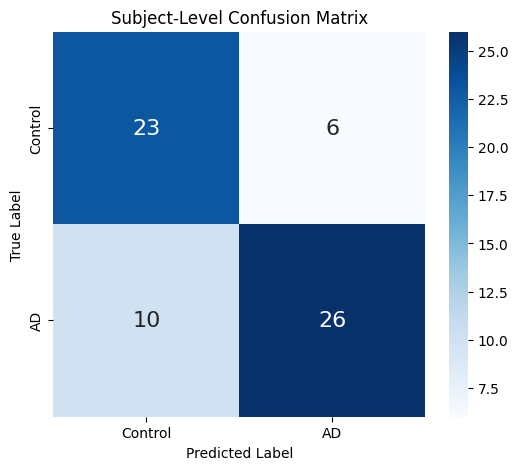

Generating Trial Accuracy Chart...


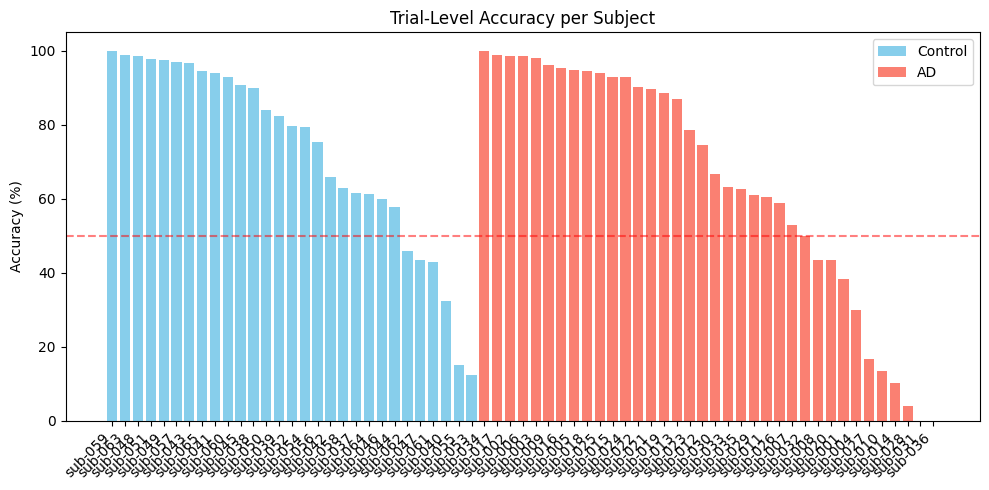


Visualization complete!


In [7]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd
import os

def load_results(json_path="results/loso_results.json"):
    if not os.path.exists(json_path):
        print(f"Error: Could not find {json_path}. Please run the pipeline first.")
        return None
    with open(json_path, 'r') as f:
        data = json.load(f)
        if isinstance(data, list):
            if data:
                return data[-1]  # Return the most recent run
            else:
                print(f"Error: '{json_path}' is an empty list. No results to display.")
                return None
        elif isinstance(data, dict):
            return data  # Already a single run
        else:
            print(f"Error: '{json_path}' contains unexpected data format. Expected a dict or a list of dicts.")
            return None

def plot_confusion_matrix(results, ax=None):
    y_true = [fold['y_true'] for fold in results['folds']]
    y_pred = [fold['y_pred'] for fold in results['folds']]

    cm = confusion_matrix(y_true, y_pred)
    df_cm = pd.DataFrame(cm, index=['Control', 'AD'], columns=['Control', 'AD'])

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    sns.heatmap(df_cm, annot=True, fmt='g', cmap='Blues', ax=ax, annot_kws={"size": 16})
    ax.set_title('Subject-Level Confusion Matrix')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

    return ax.figure

def plot_trial_accuracy(results, ax=None):
    df = pd.DataFrame(results['folds'])

    # Sort by true label so Controls and ADs are grouped
    df.sort_values(by=['y_true', 'trial_accuracy'], ascending=[True, False], inplace=True)

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))

    colors = ['skyblue' if y == 0 else 'salmon' for y in df['y_true']]
    bars = ax.bar(df['subject'], df['trial_accuracy'] * 100, color=colors)

    ax.axhline(50, color='red', linestyle='--', alpha=0.5, label='Random Chance')
    ax.set_title('Trial-Level Accuracy per Subject')
    ax.set_ylabel('Accuracy (%)')
    ax.set_xticks(range(len(df['subject'])))
    ax.set_xticklabels(df['subject'], rotation=45, ha='right')

    # Custom legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='skyblue', label='Control'),
                       Patch(facecolor='salmon', label='AD')]
    ax.legend(handles=legend_elements)

    plt.tight_layout()
    return ax.figure

def main():
    results = load_results()
    if not results:
        return

    os.makedirs('results/figures', exist_ok=True)

    print(f"Loaded results! Final Subject-Level Accuracy: {results['subject_level_accuracy']*100:.2f}%")
    print(f"Target Accuracy (Original Paper): {results.get('paper_target_accuracy', 0.8615)*100:.2f}%\n")

    # 1. Plot Confusion Matrix
    print("Generating Confusion Matrix...")
    fig_cm = plot_confusion_matrix(results)
    plt.show(fig_cm)

    # 2. Plot Trial Accuracy
    print("Generating Trial Accuracy Chart...")
    fig_acc = plot_trial_accuracy(results)
    plt.show(fig_acc)

    print("\nVisualization complete!")

if __name__ == "__main__":
    main()

In [8]:
import yaml

config_path = "config.yml"

if os.path.exists(config_path):
    with open(config_path, 'r') as f:
        config_content = yaml.safe_load(f)
    print("Current config.yml content:")
    print(yaml.dump(config_content, indent=4))
else:
    print(f"Error: {config_path} not found. Please ensure it exists in your working directory.")

Current config.yml content:
data:
    photic: ./data/processed/ds006036
    resting: ./data/raw/ds004504
experiment:
    binary_classification: true
    dataset: photic
    n_splits: 5
    seed: 42
model:
    params:
        num_kernels: 10000
        num_models: 10
    type: detach_rocket

